<a href="https://colab.research.google.com/github/xbanuelos/BI-Portfolio/blob/main/phase_01/project_02_delivery_time/delivery_time_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delivery Time Analysis

**Dataset:** Olist Brazilian E-Commerce (Kaggle)

**Business Questions**
1. What percentage of orders arrive late vs the estimated delivery date?

8.1% of delivered orders arrived after the estimated delivery date (7,826 out of ~96k orders). Aditionally, 5.2% of delivered orders had abnormally long delivery times (outliers beyond Q3 + 1.5xIQR), with extreme cases reaching 209 days.

2. Which states have the highes late delivery rates? (customer location)

The segment average across states is ~11%, above the global 8.1% - meaning late deliveries are not evenly distributed across the country. The states who concentrate the worst perforamnces: AL (23.9%), MA (19.7%), PI (16.0%), and CE (15.3%). All of whom concentrated to Brazil´s norteast region. In contrast, RO (2.9%), AM (4.1%), and PR (5%) are the best performing states. The geographic pattern suggest a last-mile infrastructure problem in the northeast not a seller or product issue.

3. Which products categories are most prone to late deliveries?

The segment average for categories (~7.5) is actually below the global (8.1%), meaning most categories perform betthen than the overall business average.

Audio (12.7%), fashion_underwear_e_moda_praia (12.6%), and artigos_de_natal (12%) are the worst performing categories - ~1.5x the average. The christmas products result is expected given seasonal demand skipes. Audio and beachwear suggest supply chain issues specific to those sellers networks.

4. Which seller states generate the most delays? (seller location)

The segment average for seller states is ~6.5%, bellow the global 8.1%, meaning most sellers actually outperform the business average. MA is the only true outlier at 23.6%, nearly 4x its segment average. SP sellers (8.5%) are slightly above the global average but within normal range given their volume. This isolates MA-based sellers as a specific operational risk woth audit.

5. Are there seasonal patterns in late deliveries? (month analysis)

The segment average across month is ~6.5%, confirming that most month perform better than the global 8.1% Two clear anomaly clusters emerge:
- November 2017 (13.8%) - black friday demand spike
- Q1 2018: worth a deeper exploration to find causality.

**Overall recommendation**

The delivery problem is higly concentrated in three dimensions: norhteast customer states (MA, AL, PI), MA-based sellers, and Q1 + November months. Addressing these three nodes specifically could resolve the majority of late delivery complaints at minimal cost.

**Limitation**

The dataset does not include carrier/logistics provider information, so we cannot attribute delays to specific shipping companies.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

order_items = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_reviews_dataset.csv')
order = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_customers_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_products_dataset.csv')
cat_translation = pd.read_csv('/content/drive/MyDrive/BI Portfolio/product_category_name_translation.csv')
sellers = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_sellers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_geolocation_dataset.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def get_iqr_limit(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return round(Q3 + 1.5 * IQR, 1)

In [ ]:
data_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

order[data_cols] = order[data_cols].apply(pd.to_datetime)

In [ ]:
#how many days did delivery take?
order['delivery_days'] = (
    order['order_delivered_customer_date'] - order['order_purchase_timestamp']
    ).dt.days

In [ ]:
#only delivered orders
delivered = order[order['order_status'] == 'delivered'].dropna(subset=['delivery_days'])

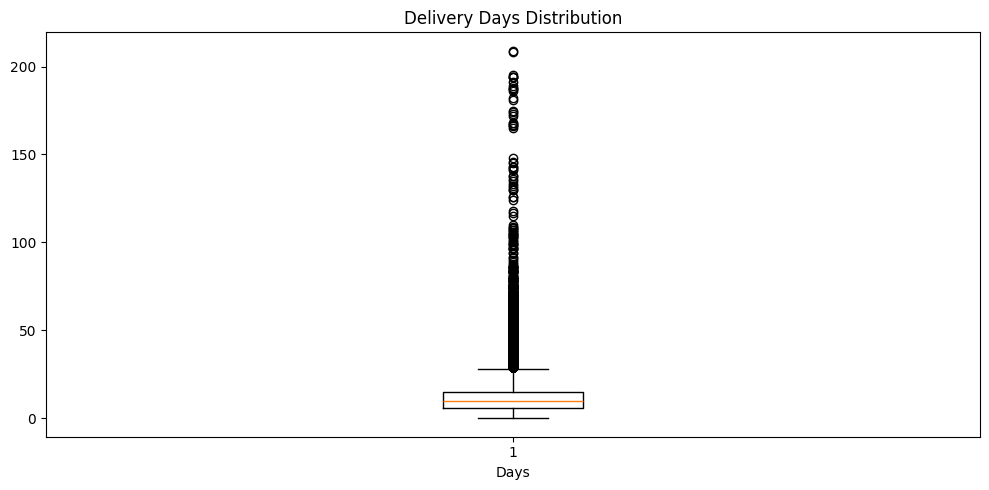

In [ ]:
#boxplot
fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(delivered['delivery_days'])

ax.set_title('Delivery Days Distribution')
ax.set_xlabel('Days')

plt.tight_layout()
plt.show()

In [ ]:
q1 = delivered['delivery_days'].quantile(0.25)
q3 = delivered['delivery_days'].quantile(0.75)
iqr = q3 - q1

outliers = delivered[delivered['delivery_days'] > q3 + 1.5 * iqr]

print(f"Q1: {q1} días")
print(f"Q3: {q3} días")
print(f"IQR: {iqr} días")
print(f"Límite outlier: {q3 + 1.5 * iqr} días")
print(f"Total outliers: {len(outliers)} órdenes ({round(len(outliers)/len(delivered)*100, 1)}%)")
print(f"Mediana: {delivered['delivery_days'].median()} días")
print(f"Max: {delivered['delivery_days'].max()} días")

Q1: 6.0 días
Q3: 15.0 días
IQR: 9.0 días
Límite outlier: 28.5 días
Total outliers: 5022 órdenes (5.2%)
Mediana: 10.0 días
Max: 209.0 días


In [ ]:
delivered['is_late'] = (
    delivered['order_delivered_customer_date'] >
    delivered['order_estimated_delivery_date']
)

print(f"Late orders: {delivered['is_late'].sum():,}")
print(f"Late rate: {round(delivered['is_late'].mean()*100,1)}")

Late orders: 7,826
Late rate: 8.1


In [ ]:
delivered = delivered.merge(customers[['customer_id', 'customer_state']],
                            on='customer_id', how='inner')

In [ ]:
#late rate por estado

late_by_state = delivered.groupby('customer_state').agg(
    total_orders=('order_id','count'),
    late_orders=('is_late','sum')
).reset_index()

late_by_state['late_rate'] = (late_by_state['late_orders'] /
                                   late_by_state['total_orders'] * 100).round(1)

#solo estados con volumen significativo y ordenados por late rate
late_by_state = late_by_state[late_by_state['total_orders'] > 100]
late_by_state = late_by_state.sort_values('late_rate', ascending=False)

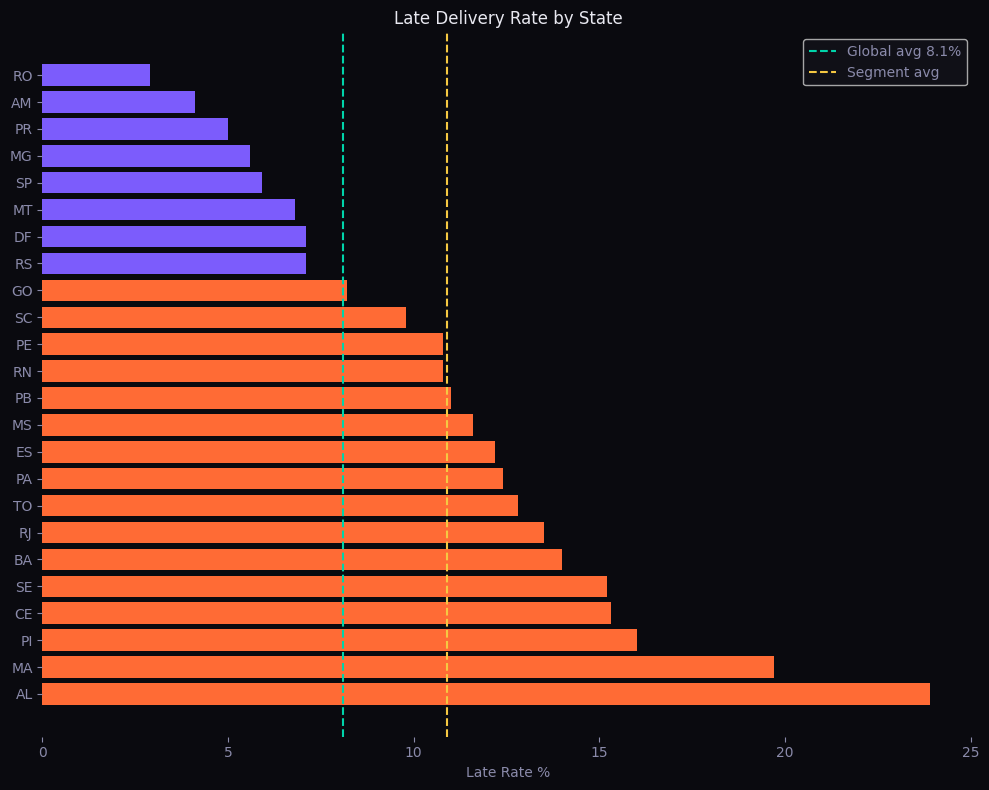

In [ ]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(late_by_state['customer_state'],
               late_by_state['late_rate'],
               color=['#ff6b35' if r > 8.1 else '#7c5cfc'
                      for r in late_by_state['late_rate']])

segment_avg = late_by_state['late_rate'].mean()

ax.axvline(x=8.1, color='#00d4aa', linestyle='--', linewidth=1.5, label='Global avg 8.1%')
ax.axvline(x=segment_avg, color='#f5c842', linestyle='--', linewidth=1.5,
           label=f'Segment avg')

ax.set_title('Late Delivery Rate by State', color='#e8e8f0')
ax.set_xlabel('Late Rate %', color='#8a8aaa')
ax.legend(facecolor='#12121a', labelcolor='#8a8aaa')
ax.set_facecolor('#0a0a0f')
fig.patch.set_facecolor('#0a0a0f')
ax.tick_params(colors='#8a8aaa')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print(order_items.columns.tolist())
print(order_items.head(2))

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  


In [ ]:
#unir todos los datasets con delivered
delivered = delivered.merge(order_items[['order_id','product_id','seller_id']],
                            on='order_id', how='inner')
delivered = delivered.merge(products[['product_id','product_category_name']],
                            on='product_id', how='inner')

#late rate por categoría
late_by_category = delivered.groupby('product_category_name').agg(
    total_orders=('order_id','count'),
    late_orders=('is_late','sum')
).reset_index()

late_by_category['late_rate'] = (late_by_category['late_orders'] /
                                 late_by_category['total_orders'] * 100).round(1)
#filtrar categorías con volumen significativo y top/bottom 10

late_by_category = late_by_category[late_by_category['total_orders'] > 100]
late_by_category = late_by_category.sort_values('late_rate', ascending=False)

#top 10 mejores y 10 peores
top_bottom = pd.concat([
    late_by_category.head(10),
    late_by_category.tail(10)])

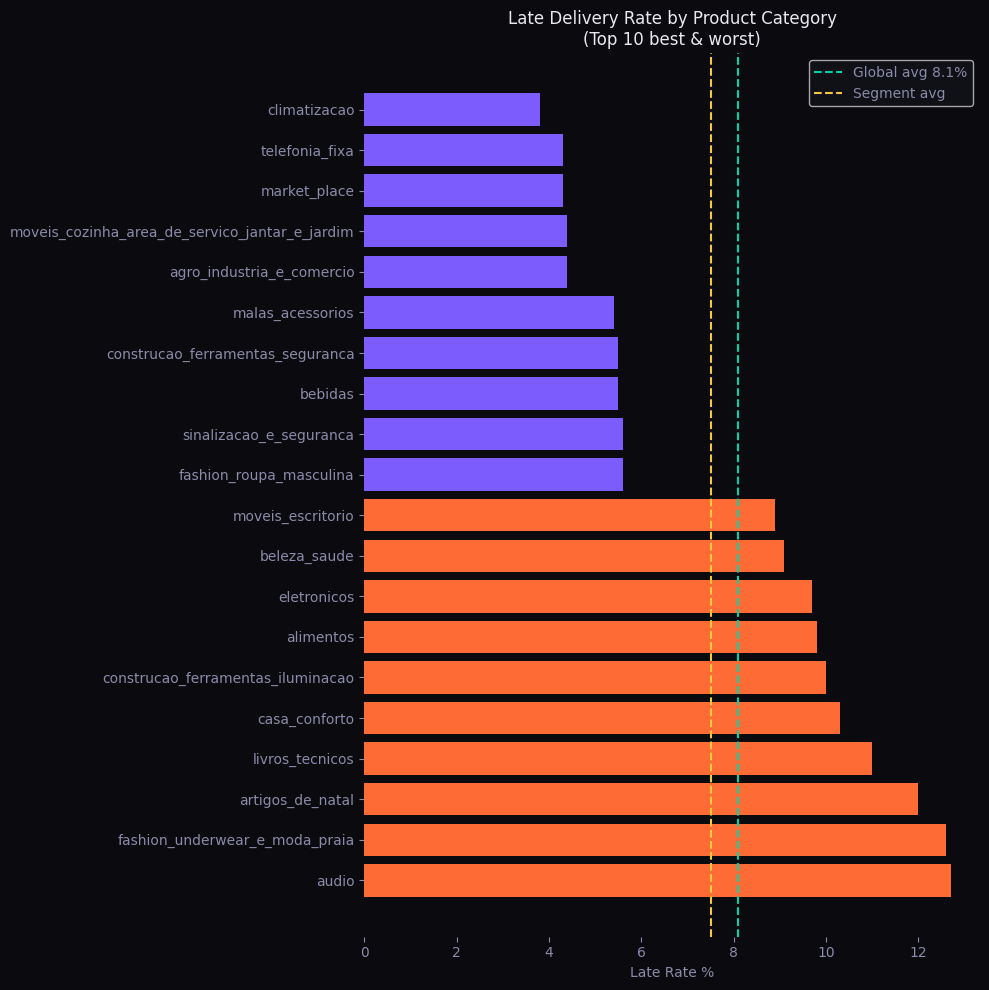

In [ ]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(top_bottom['product_category_name'],
               top_bottom['late_rate'],
               color=['#7c5cfc' if r <= 8.1 else '#ff6b35'
                      for r in top_bottom['late_rate']])
segment_avg = late_by_category['late_rate'].mean()

ax.axvline(x=8.1, color='#00d4aa', linestyle='--', linewidth=1.5, label='Global avg 8.1%')
ax.axvline(x=segment_avg, color='#f5c842', linestyle='--', linewidth=1.5,
           label=f'Segment avg')

ax.set_title('Late Delivery Rate by Product Category\n(Top 10 best & worst)',
             color='#e8e8f0')
ax.set_xlabel('Late Rate %', color='#8a8aaa')
ax.legend(facecolor='#12121a', labelcolor='#8a8aaa')
ax.set_facecolor('#0a0a0f')
fig.patch.set_facecolor('#0a0a0f')
ax.tick_params(colors='#8a8aaa')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,customer_state,product_id,seller_id,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,False,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,False,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria


In [ ]:
delivered = delivered.merge(sellers[['seller_id','seller_state']],
                            on = 'seller_id', how='inner')

In [ ]:
late_by_seller = delivered.groupby('seller_state').agg(
    total_orders=('order_id','count'),
    late_orders=('is_late','sum')
).reset_index()

late_by_seller['late_rate'] = (late_by_seller['late_orders']/
                               late_by_seller['total_orders']*100).round(1)

late_by_seller = late_by_seller[late_by_seller['total_orders'] > 100]
late_by_seller = late_by_seller.sort_values('late_rate', ascending=False)

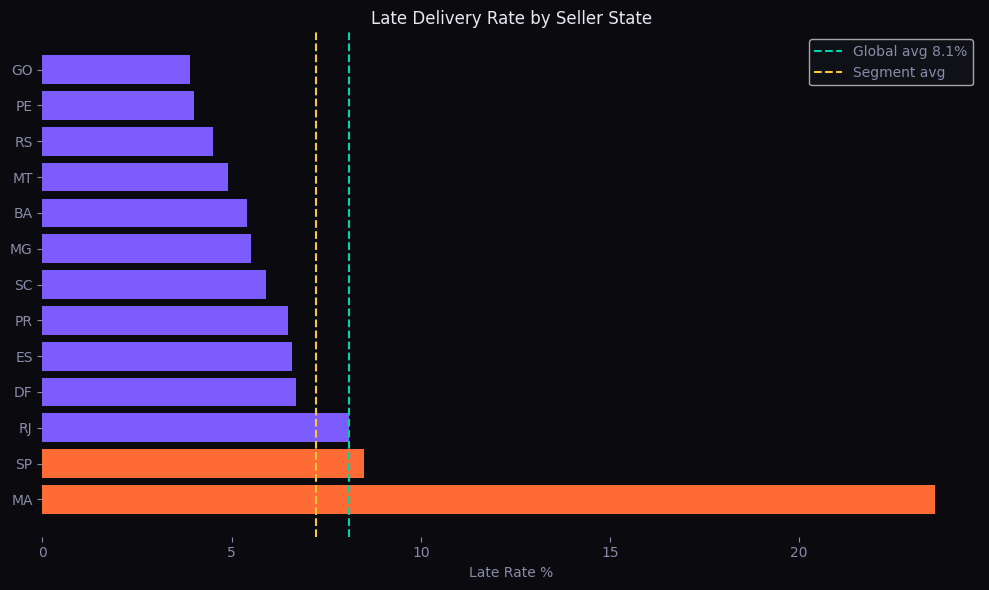

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(late_by_seller['seller_state'],
               late_by_seller['late_rate'],
               color=['#7c5cfc' if r <= 8.1 else '#ff6b35'
                      for r in late_by_seller['late_rate']])

segment_avg = late_by_seller['late_rate'].mean()

ax.axvline(x=8.1, color='#00d4aa', linestyle='--', linewidth=1.5, label='Global avg 8.1%')
ax.axvline(x=segment_avg, color='#f5c842', linestyle='--', linewidth=1.5,
           label=f'Segment avg')

ax.set_title('Late Delivery Rate by Seller State', color='#e8e8f0')
ax.set_xlabel('Late Rate %', color='#8a8aaa')
ax.legend(facecolor='#12121a', labelcolor='#8a8aaa')
ax.set_facecolor('#0a0a0f')
fig.patch.set_facecolor('#0a0a0f')
ax.tick_params(colors='#8a8aaa')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#seasonal sale

delivered['month'] = delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)

#late rate por mes
late_by_month = delivered.groupby('month').agg(
    total_orders=('order_id','count'),
    late_orders=('is_late','sum')
).reset_index()
late_by_month = late_by_month[late_by_month['total_orders'] > 50]
late_by_month['late_rate'] = (late_by_month['late_orders'] / late_by_month['total_orders'] * 100).round(1)

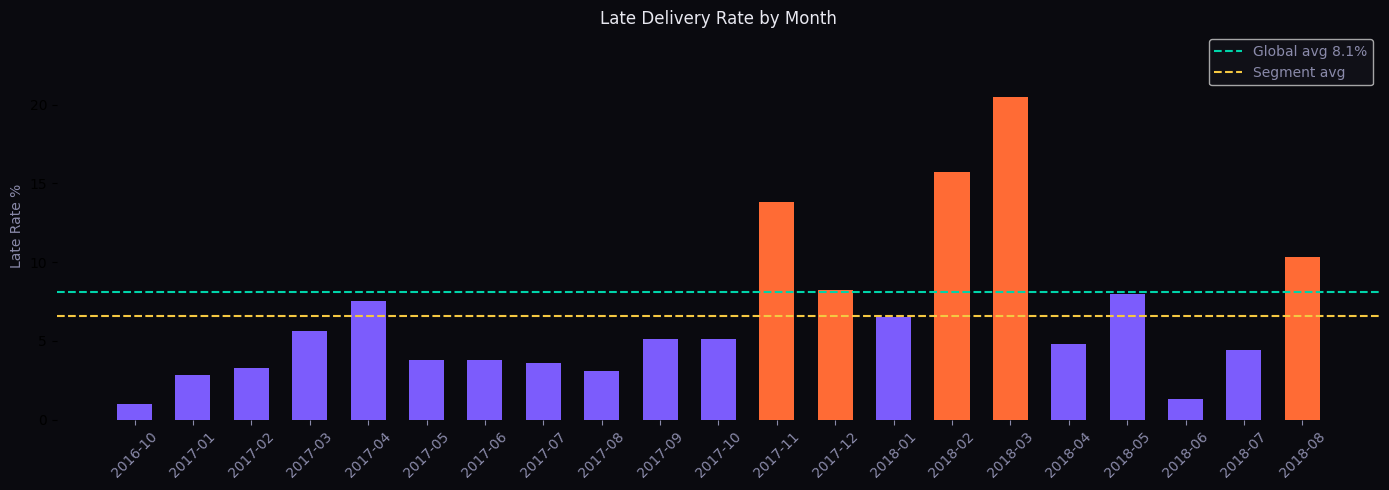

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(late_by_month['month'], late_by_month['late_rate'],
              color=['#ff6b35' if r > 8.1 else '#7c5cfc' for r in late_by_month['late_rate']],
              width=0.6)

segment_avg = late_by_month['late_rate'].mean()

ax.axhline(y=8.1, color='#00d4aa', linestyle='--', linewidth=1.5, label='Global avg 8.1%')
ax.axhline(y=segment_avg, color='#f5c842', linestyle='--', linewidth=1.5,
           label=f'Segment avg')

ax.set_title('Late Delivery Rate by Month', color='#e8e8f0')
ax.set_ylabel('Late Rate %', color='#8a8aaa')
ax.set_ylim(0, late_by_month['late_rate'].max() * 1.2)
ax.legend(facecolor='#12121a', labelcolor='#8a8aaa')
ax.set_facecolor('#0a0a0f')
fig.patch.set_facecolor('#0a0a0f')
ax.tick_params(colors='#8a8aaa', axis='x', rotation=45)
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

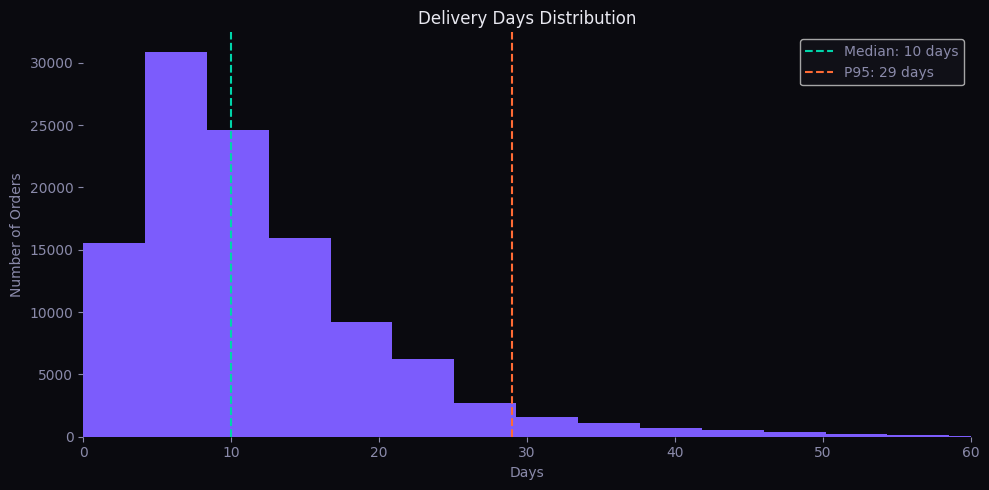

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(delivered['delivery_days'], bins=50, color='#7c5cfc', edgecolor='none')

ax.axvline(delivered['delivery_days'].median(), color='#00d4aa',
           linestyle='--', linewidth=1.5, label=f"Median: {delivered['delivery_days'].median():.0f} days")
ax.axvline(delivered['delivery_days'].quantile(0.95), color='#ff6b35',
           linestyle='--', linewidth=1.5, label=f"P95: {delivered['delivery_days'].quantile(0.95):.0f} days")

ax.set_title('Delivery Days Distribution', color='#e8e8f0')
ax.set_xlabel('Days', color='#8a8aaa')
ax.set_ylabel('Number of Orders', color='#8a8aaa')
ax.legend(facecolor='#12121a', labelcolor='#8a8aaa')
ax.set_facecolor('#0a0a0f')
fig.patch.set_facecolor('#0a0a0f')
ax.tick_params(colors='#8a8aaa')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.set_xlim(0, 60)

plt.tight_layout()
plt.show()

## Insight 1
8.1% de las ordenes entregadas (7,826) llegan después de la fecha estimada de entrega. Hay rangos de entrega entre 0 a 209 días, con una media de ~10 días y 5.2% clasificaron como outliers (>27 días).

## Insight 2
El 5.2% de las órdenes entreganas superaron el límite esperado de entrega 'Q3 + 1.5*IQR'. En un volumen de ~96k órdenes, esto representa ~5,000 clientes con experiencias de entrega anormalmente largas, con casos extremos de hasta 209 días.

## Insight 3
Estados al noreste de Brazy tienen un problema severo con registros de entregas tardías: AI (23.9%), MA (19.7%), and PI(16.0%) son los peores performers, presentando más del doble del promedio nacional. En contraste, RO (2.9%), AM (4.1%), and PR(5.0%) sobresalen constantemente. Esto apunto a un gap en infraestructura en el noreste más que un error de la empresa de entregas.

## Insight 4
Las categorías audio (12.7%) y moda playera (12.6%) tienen la tasa de entrega tardía más alta - casi 1.5x el promedio. El tamaño del producto no parece ser un factor determinante, lo que sugiere problemas en la cadena de suministro específica de esos sellers.

## Insight 5
Picos de entregas tardias en Noviembre 2017 (13.8%) - se alinea con la demanda de Black Friday - y más pronunciadamente en el Q1 2018, teniendo un peak de 20.5% en Marzo. Este patrón del primer trimestre, que se repite entre enero y marzo, sugiere una acumulación estructural posterior a las vacaciones, en lugar de un evento puntual.  

**Recomendaciones**
Olist deberia priorizar las siguientes intervenciones:
1. Fortalecer las alianzas con transportistas de última milla, especificamente en AL, MA, PI, CE and SE, antes de la temporada alta.

2. Ajustar la predicción de fechas de entrega estimadas durante noviembre y el primer trimestre para gestionar las expectativas de los cleintes y reducir el impacto en su satisfacción.